# Ejercicio 1

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import corner

Datos generados. Mostrando el gráfico para la inspección visual...


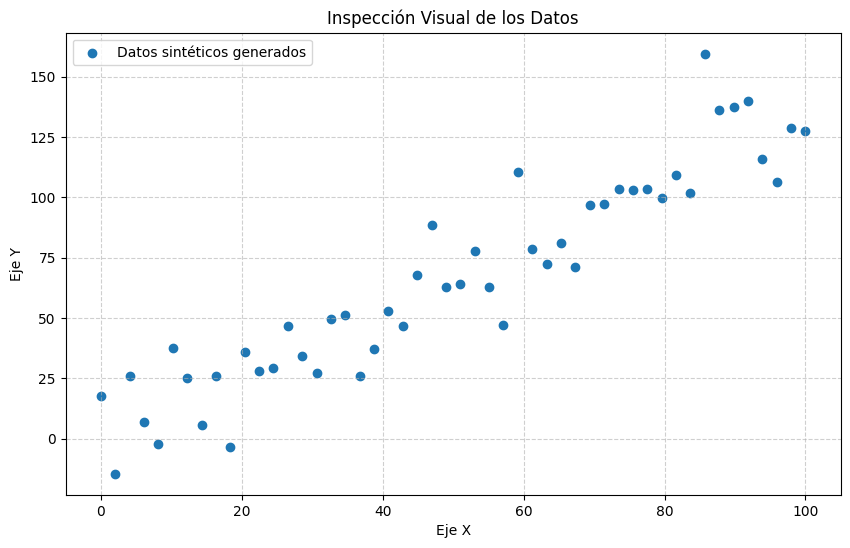

In [32]:

# --- 1. Definimos los parámetros "verdaderos" de nuestro modelo ---
# Estos son los valores que nuestro MCMC intentará descubrir.
a_verdadero = 2.5      # Ordenada al origen (intercept)
b_verdadero = 1.3      # Pendiente (slope)
sigma_verdadero = 15.0 # Desviación estándar del ruido (qué tan dispersos están los puntos)

# --- 2. Generamos los datos sintéticos ---
N = 50  # El ejercicio pide generar 50 datos [cite: 44]
x = np.linspace(0, 100, N)  # Generamos 50 puntos para 'x' entre 0 y 100

# Calculamos 'y' usando la ecuación de la recta (el modelo ideal)
y_modelo = a_verdadero + b_verdadero * x

# Creamos el ruido gaussiano para simular errores de medición
# El ruido tiene media 0 y desviación estándar 'sigma_verdadero'
ruido = np.random.normal(0, sigma_verdadero, N)

# Los datos finales 'y' son el modelo ideal más el ruido
y = y_modelo + ruido

# --- 3. Graficamos los datos para la inspección visual ---
print("Datos generados. Mostrando el gráfico para la inspección visual...")

plt.figure(figsize=(10, 6))
# Usamos scatter para mostrar los puntos individuales
plt.scatter(x, y, label='Datos sintéticos generados')
plt.title('Inspección Visual de los Datos')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Vamos a utilizar un enfoque bayesiano y mcmc, para determinar los mejores parametros del ajuste 

Iniciando MCMC...
Paso 5000/50000...
Paso 10000/50000...
Paso 15000/50000...
Paso 20000/50000...
Paso 25000/50000...
Paso 30000/50000...
Paso 35000/50000...
Paso 40000/50000...
Paso 45000/50000...
Tasa de aceptación final: 0.39
¡MCMC completado!

Generando gráficos de resultados...


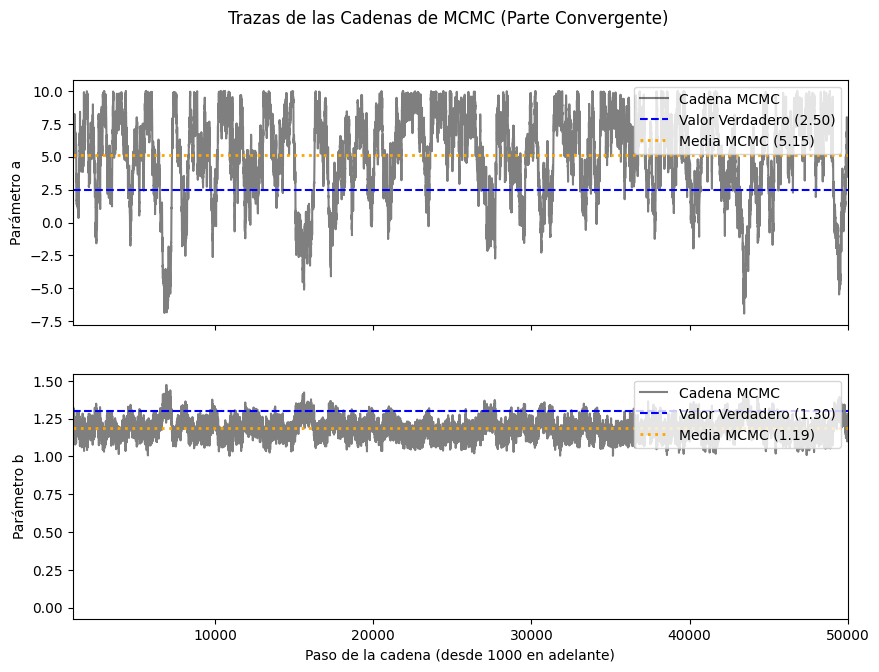

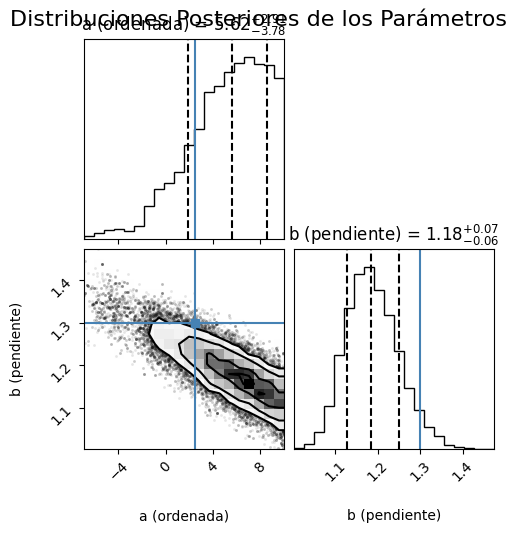


--- Comparación de Resultados ---
Valor Verdadero:     a = 2.500, b = 1.300
Solución Analítica:  a = 6.476, b = 1.168
Resultado MCMC:      a = 5.620, b = 1.184


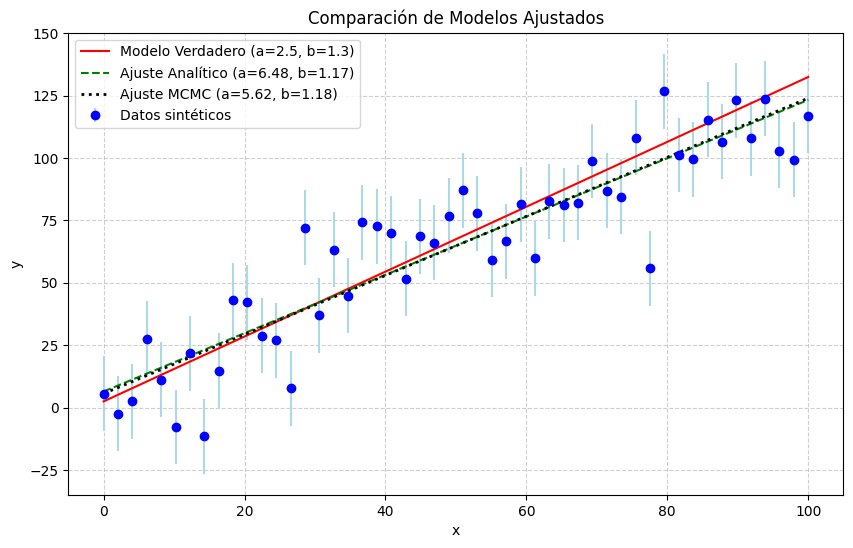

Generando gráfico del camino del MCMC...


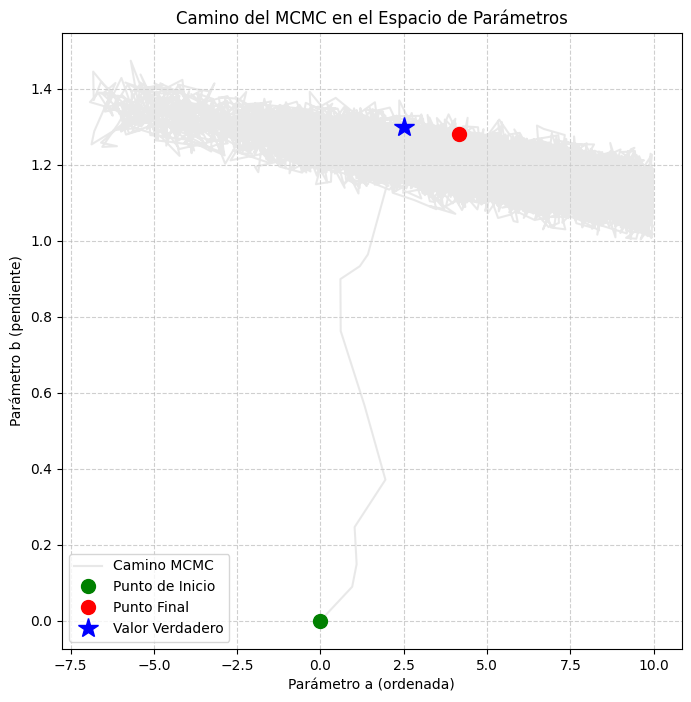

In [ ]:

# --- 1. Generación de Datos (como antes) ---
a_verdadero = 2.5
b_verdadero = 1.3
sigma_verdadero = 15.0
N = 50
x = np.linspace(0, 100, N)
y_modelo = a_verdadero + b_verdadero * x
ruido = np.random.normal(0, sigma_verdadero, N)
y = y_modelo + ruido

# --- 2. Modelo Bayesiano (como antes) ---
def log_likelihood(params, x, y):
    a, b = params
    sigma = sigma_verdadero
    y_modelo = a + b * x
    log_L = -0.5 * np.sum(((y - y_modelo) / sigma)**2)
    return log_L

def log_prior(params):
    a, b = params
    # Rangos amplios basados en la inspección visual
    if -10.0 < a < 10.0 and -5.0 < b < 5.0:
        return 0.0
    return -np.inf

def log_posterior(params, x, y):
    lp = log_prior(params)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(params, x, y)

# --- 3. MCMC - Algoritmo de Metrópolis-Hastings (como antes) ---
def run_mcmc(start_position, n_steps, x, y):
    chain = np.zeros((n_steps, 2))
    chain[0] = start_position
    current_log_posterior = log_posterior(chain[0], x, y)
    accepted_steps = 0

    for i in range(1, n_steps):
        if i % 5000 == 0:
            print(f"Paso {i}/{n_steps}...")

        step_size = [0.5, 0.1]
        proposal = chain[i-1] + np.random.normal(scale=step_size, size=2)
        proposal_log_posterior = log_posterior(proposal, x, y)
        
        log_acceptance_ratio = proposal_log_posterior - current_log_posterior
        
        if np.log(np.random.rand()) < log_acceptance_ratio:
            chain[i] = proposal
            current_log_posterior = proposal_log_posterior
            accepted_steps += 1
        else:
            chain[i] = chain[i-1]
            
    # Calculamos la tasa de aceptación, un buen diagnóstico del MCMC
    acceptance_rate = accepted_steps / n_steps
    print(f"Tasa de aceptación final: {acceptance_rate:.2f}")
    return chain

# --- Corremos la simulación ---
n_steps = 50000
start_pos = [0.0, 0.0] 
print("Iniciando MCMC...")
chain = run_mcmc(start_pos, n_steps, x, y)
print("¡MCMC completado!")

# --- 4. Análisis y Visualización de Resultados ---
print("\nGenerando gráficos de resultados...")

# Descartamos el "burn-in"
burn_in = 1000
chain_final = chain[burn_in:]

# --- CÁLCULO DE LAS MEDIAS ---
# Calculamos la media de la cadena después del burn-in
a_mcmc_mean = np.mean(chain_final[:, 0])
b_mcmc_mean = np.mean(chain_final[:, 1])
# --- FIN DEL NUEVO CÁLCULO ---

# Gráfico 1: "Trace plots" o Trazas de las cadenas (Mostrando solo la parte convergente)
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)

# Trazas para 'a'
axes[0].plot(chain[:, 0], 'k-', alpha=0.5, label='Cadena MCMC')
axes[0].set_ylabel('Parámetro a')
axes[0].axhline(a_verdadero, color='blue', linestyle='--', label=f'Valor Verdadero ({a_verdadero:.2f})')
# --- LÍNEA AÑADIDA ---
axes[0].axhline(a_mcmc_mean, color='orange', linestyle=':', lw=2, label=f'Media MCMC ({a_mcmc_mean:.2f})')
axes[0].legend(loc='upper right') # Muevo la leyenda para mejor visibilidad

# Trazas para 'b'
axes[1].plot(chain[:, 1], 'k-', alpha=0.5, label='Cadena MCMC')
axes[1].set_ylabel('Parámetro b')
axes[1].set_xlabel(f'Paso de la cadena (desde {burn_in} en adelante)')
axes[1].axhline(b_verdadero, color='blue', linestyle='--', label=f'Valor Verdadero ({b_verdadero:.2f})') 
# --- LÍNEA AÑADIDA ---
axes[1].axhline(b_mcmc_mean, color='orange', linestyle=':', lw=2, label=f'Media MCMC ({b_mcmc_mean:.2f})')
axes[1].legend(loc='upper right') # Muevo la leyenda

# Ajustamos el límite izquierdo del eje X para que comience
# justo después del burn-in.
axes[1].set_xlim(burn_in, n_steps)

fig.suptitle('Trazas de las Cadenas de MCMC (Parte Convergente)')
plt.show()

# (El resto de tu código para Gráfico 2, 3, etc. sigue aquí...)

# Gráfico 2: "Corner plot"
# Este es el gráfico más importante. Muestra las distribuciones de probabilidad
# de cada parámetro (histogramas en la diagonal) y las correlaciones entre ellos.
figure = corner.corner(
    chain_final,
    labels=['a (ordenada)', 'b (pendiente)'],
    truths=[a_verdadero, b_verdadero], # Dibuja una línea en el valor verdadero
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)
figure.suptitle('Distribuciones Posteriores de los Parámetros', fontsize=16)
plt.show()

# --- 5. Comparación con la Solución Analítica ---

# El método de Mínimos Cuadrados nos da una solución analítica directa.
# np.polyfit(x, y, 1) ajusta un polinomio de grado 1 (una recta)
b_analitico, a_analitico = np.polyfit(x, y, 1)

# Extraemos los valores más probables del MCMC (la mediana del posterior)
a_mcmc = np.median(chain_final[:, 0])
b_mcmc = np.median(chain_final[:, 1])

print("\n--- Comparación de Resultados ---")
print(f"Valor Verdadero:     a = {a_verdadero:.3f}, b = {b_verdadero:.3f}")
print(f"Solución Analítica:  a = {a_analitico:.3f}, b = {b_analitico:.3f}")
print(f"Resultado MCMC:      a = {a_mcmc:.3f}, b = {b_mcmc:.3f}")


# Gráfico 3: Visualización del ajuste en los datos
plt.figure(figsize=(10, 6))
plt.errorbar(x, y, yerr=sigma_verdadero, fmt='o', color='blue', ecolor='lightblue', capsize=0, label='Datos sintéticos')
plt.plot(x, y_modelo, 'r-', label=f'Modelo Verdadero (a={a_verdadero}, b={b_verdadero})')
plt.plot(x, a_analitico + b_analitico * x, 'g--', label=f'Ajuste Analítico (a={a_analitico:.2f}, b={b_analitico:.2f})')
plt.plot(x, a_mcmc + b_mcmc * x, 'k:', linewidth=2, label=f'Ajuste MCMC (a={a_mcmc:.2f}, b={b_mcmc:.2f})')
plt.title('Comparación de Modelos Ajustados')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# --- Gráfico 4: Visualización del Camino del MCMC ---
print("Generando gráfico del camino del MCMC...")

plt.figure(figsize=(8, 8))
# Dibuja el camino completo con un poco de transparencia para ver la densidad
plt.plot(chain[:, 0], chain[:, 1], '-', color='lightgrey', alpha=0.5, label='Camino MCMC')

# Marca el punto de inicio con un círculo verde
plt.plot(chain[0, 0], chain[0, 1], 'o', color='green', markersize=10, label='Punto de Inicio')

# Marca el punto final con un círculo rojo
plt.plot(chain[-1, 0], chain[-1, 1], 'o', color='red', markersize=10, label='Punto Final')

# Marca el valor verdadero con una estrella azul para referencia
plt.plot(a_verdadero, b_verdadero, '*', color='blue', markersize=15, label='Valor Verdadero')

plt.title('Camino del MCMC en el Espacio de Parámetros')
plt.xlabel('Parámetro a (ordenada)')
plt.ylabel('Parámetro b (pendiente)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
# Opcional: ajusta los límites si el camino se sale mucho del área de interés
# plt.xlim(a_mcmc - 5, a_mcmc + 5)
# plt.ylim(b_mcmc - 1, b_mcmc + 1)
plt.show()